### Robustness tests for irrigated fraction and gauge density and coverage
Lesk and Mankin 2026 Nature

This analysis uses basin-level effects as well as global panel regression results from Fig. 2 (code reproduced here in case useful).




In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
# data directories
root_dir = '/dartfs-hpc/rc/lab/C/CMIG'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'


In [3]:
#conversion factors
cm_to_mm = 10
scale = 0.1

In [4]:
# data processing functions
def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

def flipLon360(ds):
    # converts -180-180 lon to 0-360
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def fixLonLine(ds):
    # wrap cyclic point to avoid nans at lon=0 when plotting
    
    # fill the NaNs in the last column with the values from the adjacent column
    last_valid_lon_index = ds.lon.argmax().item()   
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index -1].where(np.isnan(ds[:, last_valid_lon_index]), ds[:, last_valid_lon_index])

    return ds

def fixLonLine2(ds):
    # alternative wrap cyclic point to avoid nans at lon=0 when plotting

    # ensure there are valid lon values to process
    if ds.lon.size == 0 or np.isnan(ds.lon).all():
        raise ValueError("Longitude array is empty or all values are NaN.")

    # find the index of the last valid column before lon=0
    valid_lons = ds.lon.values
    last_valid_lon_index = np.nanargmax(valid_lons) - 1  # One before the last

    # last_valid_lon_index is valid
    if last_valid_lon_index < 0:
        raise ValueError("No valid longitude values before 0.")

    # Fill the NaNs in the last column with the values from the adjacent column
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index - 1].where(
        np.isnan(ds[:, last_valid_lon_index]), 
        ds[:, last_valid_lon_index]
    )

    return ds


### setup basin shapefile

In [5]:
# load basin shapefile
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

In [6]:
# load basin scale results and full panel
basin_models = pd.read_csv(save_dir+'basin_models_no_interaction_GPCC.csv')
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')

#load processed basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')

#merge onto full df
pexq_df['basin_id'] = basin_id_df['basin_id']

In [7]:
# gather basin names (for identifying basins)
names = []
for i in basin_models['basin_id']:
    names.append(grdc_basins[grdc_basins.MRBID == i].RIVER_BASI.values[0])

basin_models['basin_name'] = names

In [9]:
#bring in pmean from pexq_df dataset:
#Pmeanlist = []
#for i in basin_models.index:
#    Pmeanlist.append(pexq_df[pexq_df.basin_id == int(basin_models.loc[i].basin_id)].Pmean.mean())

#basin_models['Pmean'] = Pmeanlist

# for interaction model, compute full Gp coef and add to df:
#basin_models['dTWS/dGp'] = basin_models['coef_Gp']+basin_models['coef_Gp_Pmean']*basin_models['Pmean']*scale*cm_to_mm

grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})
merged = grdc_basins.merge(basin_models, on='basin_id', how='left')

### Fig 2. main regression results: TWS GP

In [16]:
# load absolute regression coefficients
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_regression_results.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_regression_results.csv')

In [17]:
###  calculate conditional marginal effect +/- SE
scale = 0.1 # per 0.1 gp
scale = scale*cm_to_mm
n_se = 2

#conditional coef estimates
gamma_abs = cpc_results['coef_Gp'][0]
chi_abs = cpc_results['coef_GpP'][0]
gamma_se = cpc_results['se_Gp'][0]
chi_se = cpc_results['se_GpP'][0]
cov_gamma_chi = cpc_results['vcov'][0]

#same coefs for GPCP data
gamma_gpcp_abs = gpcp_results['coef_Gp'][0]
chi_gpcp_abs = gpcp_results['coef_GpP'][0]
gamma_gpcp_se = gpcp_results['se_Gp'][0]
chi_gpcp_se = gpcp_results['se_GpP'][0]
cov_gpcp_gamma_chi = gpcp_results['vcov'][0]

# same for GPCC
gamma_gpcc_abs = gpcc_results['coef_Gp'][0]
chi_gpcc_abs = gpcc_results['coef_GpP'][0]
gamma_gpcc_se = gpcc_results['se_Gp'][0]
chi_gpcc_se = gpcc_results['se_GpP'][0]
cov_gpcc_gamma_chi = gpcc_results['vcov'][0]

# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x


In [18]:
# load standardized regression coefficients
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_std_regression_results.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_std_regression_results.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_std_regression_results.csv')

In [19]:
# standardized coefficients, 3 dataproducts
thetaS_CPC = [cpc_results['coef_T'][0],cpc_results['se_T'][0]]
piS_CPC = [cpc_results['coef_P'][0],cpc_results['se_P'][0]]
gammaS_CPC = [cpc_results['coef_Gp'][0],cpc_results['se_Gp'][0]]
chiS_CPC = [cpc_results['coef_GpP'][0],cpc_results['se_GpP'][0]]
cov_CPC = cpc_results['vcov'][0]

thetaS_GPCP = [gpcp_results['coef_T'][0],gpcp_results['se_T'][0]]
piS_GPCP = [gpcp_results['coef_P'][0],gpcp_results['se_P'][0]]
gammaS_GPCP = [gpcp_results['coef_Gp'][0],gpcp_results['se_Gp'][0]]
chiS_GPCP = [gpcp_results['coef_GpP'][0],gpcp_results['se_GpP'][0]]
cov_GPCP = gpcp_results['vcov'][0]

thetaS_GPCC = [gpcc_results['coef_T'][0],gpcc_results['se_T'][0]]
piS_GPCC = [gpcc_results['coef_P'][0],gpcc_results['se_P'][0]]
gammaS_GPCC = [gpcc_results['coef_Gp'][0],gpcc_results['se_Gp'][0]]
chiS_GPCC = [gpcc_results['coef_GpP'][0],gpcc_results['se_GpP'][0]]
cov_GPCC = gpcc_results['vcov'][0]

psample = 1000
dt_CPC = gammaS_CPC[0] + chiS_CPC[0]*psample
dtse_CPC = np.sqrt(gammaS_CPC[1]**2 + (psample**2) * chiS_CPC[1]**2 + 2 * psample * cov_CPC)
dt_GPCP = gammaS_GPCP[0] + chiS_GPCP[0]*psample
dtse_GPCP = np.sqrt(gammaS_GPCP[1]**2 + (psample**2) * chiS_GPCP[1]**2 + 2 * psample * cov_GPCP)
dt_GPCC = gammaS_GPCC[0] + chiS_GPCC[0]*psample
dtse_GPCC = np.sqrt(gammaS_GPCC[1]**2 + (psample**2) * chiS_GPCC[1]**2 + 2 * psample * cov_GPCC)
                   


In [20]:
### setup multi-obs mean at basin level 
dset = ['CPC','GPCC','GPCP']
dset_suffix = ['','_GPCC','_GPCP']

#merge all dataset results
mergedall = {}
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')
grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[0]+'.csv')
mergedall = grdc_basins.merge(basin_models[['basin_id','coef_Gp','pval_Gp']], on='basin_id', how='outer')

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[1]+'.csv')
basin_models = basin_models.rename(columns={'coef_Gp':'coef_Gp'+dset_suffix[1],'pval_Gp':'pval_Gp'+dset_suffix[1]})
mergedall = mergedall.merge(basin_models[['basin_id','coef_Gp'+dset_suffix[1],'pval_Gp'+dset_suffix[1]]], on='basin_id', how='outer')

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[2]+'.csv')
basin_models = basin_models.rename(columns={'coef_Gp':'coef_Gp'+dset_suffix[2],'pval_Gp':'pval_Gp'+dset_suffix[2]})
mergedall = mergedall.merge(basin_models[['basin_id','coef_Gp'+dset_suffix[2],'pval_Gp'+dset_suffix[2]]], on='basin_id', how='outer')

#average Gp coefficients across datasets:
mergedall['coef_Gp_mean'] = mergedall[['coef_Gp','coef_Gp_GPCC','coef_Gp_GPCP']].mean(axis=1)



In [21]:
# multi-product significance criteria:
def check_sig_consistent(row):
    # only functional for 3 products 
    # returns True if at least 2/3 products significant and same sign:
    
    # get signs of the coefficients
    signs = [np.sign(row['coef_Gp']), np.sign(row['coef_Gp_GPCC']), np.sign(row['coef_Gp_GPCP'])]
    
    # check if significant
    significant = [row['pval_Gp'] < 0.05, row['pval_Gp_GPCC'] < 0.05, row['pval_Gp_GPCP'] < 0.05]
    
    # gather coefs if have the same sign and are significant
    significant_coefs = [sign for sign, sig in zip(signs, significant) if sig]
    
    # if 3 coefs significant, cannot have a tie with 3 dataproducts, therefore sig and consist:
    if len(significant_coefs) == 3:
        return 1
    # if 2 coefs sig, can have tie: check if not tie (sum not = 0)
    elif len(significant_coefs) == 2 and sum(significant_coefs) != 0:
        return 1
    #otherwise not sig and consistent
    else:
        return 0

# Apply the function to each row of the dataframe
mergedall['sig_consist'] = mergedall.apply(check_sig_consistent, axis=1)



In [22]:
row = mergedall[mergedall.RIVER_BASI=='CHAD']
# Check the signs of the coefficients
signs = [np.sign(row['coef_Gp']).values, np.sign(row['coef_Gp_GPCC']).values, np.sign(row['coef_Gp_GPCP']).values]

# Check if p-values are significant
significant = [row['pval_Gp'].values < 0.05, row['pval_Gp_GPCC'].values < 0.05, row['pval_Gp_GPCP'].values < 0.05]

# Count how many coefficients have the same sign and are significant
significant_coefs = [sign for sign, sig in zip(signs, significant) if sig]

    

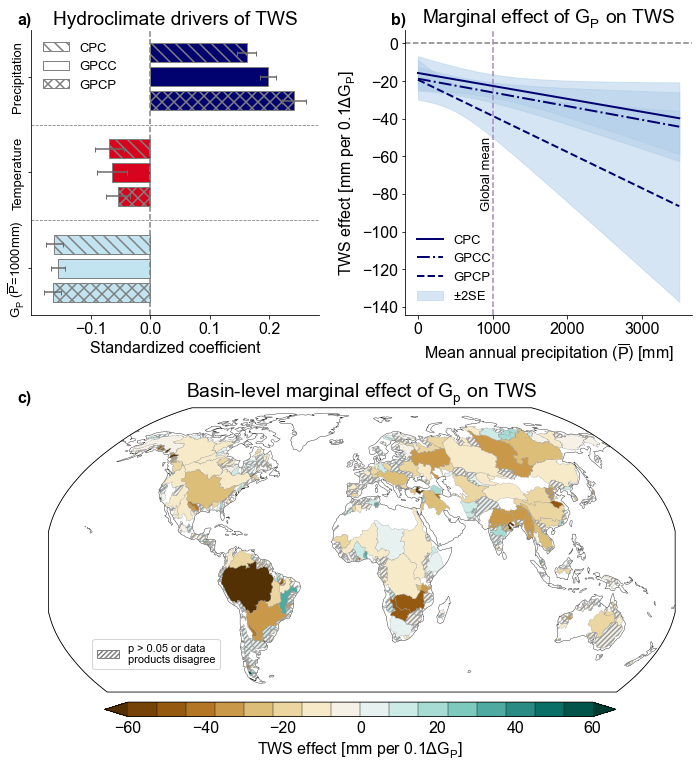

In [26]:
fig = plt.figure(figsize=(10,10))

axs = []
gs = GridSpec(2, 2)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[0,1]))
axs.append(fig.add_subplot(gs[1,:],projection=ccrs.Robinson()))

col_p = '#01016f'
col_t = '#d8031c'
col_gp = '#c2e4f0'
col_gp1000 = '#aecde8'
col_gp2000 = '#9ac2ed'
col_gp3000 = '#7bb2ed'

##############
ax = axs[1]
# a) conditional gamma
#cpc
l1=ax.plot(x,y,color=col_p,linewidth=2)
s1 = ax.fill_between(x,effecthi,effectlo,color=col_gp1000,alpha=0.5)

#gpcp
l2=ax.plot(x,ygpcp,color=col_p,linewidth=2,linestyle='--')
s2 = ax.fill_between(x,effecthi_gpcp,effectlo_gpcp,color=col_gp1000,alpha=0.5)

#gpcc
l3=ax.plot(x,ygpcc,color=col_p,linewidth=2,linestyle='-.')
s3 = ax.fill_between(x,effecthi_gpcc,effectlo_gpcc,color=col_gp1000,alpha=0.5)

ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
ax.set_ylabel('TWS effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on TWS'  )

ax.axvline(1000,linestyle='--',color='#a38bbf')
ax.text(850,-87,'Global mean',fontsize=13,rotation=90)
#legend
lg=ax.legend([l1[0],l3[0],l2[0],s1],['CPC','GPCC','GPCP',r'$\pm$'+str(n_se) + 'SE'],
             loc='lower left',facecolor='white',edgecolor='white',fontsize=13)
lg.get_frame().set_alpha(0)

ax.spines[['right', 'top']].set_visible(False)

#######################
#b) standardized
ax = axs[0]

bars = [piS_CPC[0],piS_GPCC[0],piS_GPCP[0],
        thetaS_CPC[0],thetaS_GPCC[0],thetaS_GPCP[0],
        dt_CPC,dt_GPCC,dt_GPCP]

ses = [piS_CPC[1],piS_GPCC[1],piS_GPCP[1],
        thetaS_CPC[1],thetaS_GPCC[1],thetaS_GPCP[1],
        dtse_CPC,dtse_GPCC,dtse_GPCP]

bcols = [col_p,col_p,col_p,col_t,col_t,col_t,col_gp,col_gp,col_gp]
bhatchs = ['\\\\','','XX','\\\\','','XX','\\\\','','XX']

bx = [1,2,3,5,6,7,9,10,11]

ax.barh(bx,bars,color=bcols,xerr=ses,capsize=2.5,
       error_kw={'ecolor': 'dimgrey', 'elinewidth': 1.5})
h1 = ax.barh(bx,bars,facecolor='none',edgecolor='grey',hatch=bhatchs)
ax.axvline(0,linestyle='--',color='grey')
ax.axhline(4,linestyle='--',linewidth=0.8,color='grey')
ax.axhline(8,linestyle='--',linewidth=0.8,color='grey')

ax.set_yticks([2,6,10])
ax.set_yticklabels(['Precipitation','Temperature',r'$G_P$ ($\overline{P}$=1000mm)'],va='center',rotation=90,fontsize=13)
labels = ax.get_yticklabels()
labels[2].set_position((labels[2].get_position()[0]+0.01,labels[2].get_position()[1]))

ax.set_xlabel('Standardized coefficient')

ax.invert_yaxis()

ax.legend([h1[0],h1[1],h1[2]],['CPC','GPCC','GPCP'],frameon=False,fontsize=13)

ax.set_title('Hydroclimate drivers of TWS')

ax.spines[['right', 'top']].set_visible(False)

###############
ax = axs[2]
#select column to plot
plotdat = 'coef_Gp_mean'
sigdat = 'pval_Gp'


# set colors
vmin = -60
vmax = 60
ncol = 17 # choose a number greater than
         # the number of colors you actually want
bounds = np.linspace(vmin,vmax,ncol)
cmapname = 'BrBG'
cols = plt.get_cmap(cmapname)(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = colors.Normalize(vmin=vmin,vmax=vmax)
cbar = plt.cm.ScalarMappable(norm=norm,cmap=cmap)

# map
mergedall.plot(column=plotdat,transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, linewidth=0.2, ax=ax, edgecolor='0.6', legend=False)

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='0.1',facecolor=[1,1,1],linewidth=0.4) 

#hatch_polygons = mergedall[mergedall[sigdat] > 0.05]
hatch_polygons = mergedall[mergedall['sig_consist'] < 1]

hatch_polygons.plot(transform=ccrs.PlateCarree(),
    ax=ax, 
    facecolor="none",  # no fill color for hatching layer
    edgecolor='0.6',   # neep border color consistent
    hatch='/////',      # hatch pattern
    linewidth=0.2
)

b = ax.bar(-1,-1,facecolor='none',edgecolor='grey',hatch='/////')

ax.set_title(r'Basin-level marginal effect of $G_p$ on TWS')
cbar_ax = fig.add_axes([0.16,-0.01,0.71,0.02])
plt.setp(cbar_ax.spines.values(), linewidth=0.3)
#tks = [-2,-1,0,1,2]
cb = fig.colorbar(cbar,cax=cbar_ax,orientation="horizontal",
                          drawedges=True,extend="both")#,ticks=tks)
cbar_ax.tick_params(direction="in",width=0.05)
cb.set_label(label=r"TWS effect [mm per 0.1$\Delta G_P$]")
cb.ax.tick_params(axis='x', length=0)

ax.legend([b],['p > 0.05 or data\nproducts disagree'],fontsize=11,loc=(0.07,0.08))
# lettering
lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
fig.canvas.draw()
plt.tight_layout()

plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/accepted/Fig.2.pdf',bbox_inches='tight')

### basin level effects vs irrigated area and station density

In [8]:
import rasterio

irrig_fn = '/dartfs-hpc/rc/lab/C/CMIG/Data/Other/aquastat_irrig/gmia_v5_aei_ha.asc'
gw_fn = '/dartfs-hpc/rc/lab/C/CMIG/Data/Other/aquastat_irrig/gmia_v5_aeigw_pct_aei.asc'
with rasterio.open(irrig_fn) as src:
    data = src.read(1)  # read the first (and usually only) band
    profile = src.profile  # metadata

In [10]:
## load panel
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')


## add aei to panel

with rasterio.open(irrig_fn) as src:
    # sample expects (lon, lat)
    coords = list(zip(pexq_df['lon'], pexq_df['lat']))
    irrig_vals = np.array([v[0] for v in src.sample(coords)])

irrig_vals[irrig_vals<0] = 0
pexq_df['irrig_frac_raw'] = irrig_vals

In [39]:
# area of 0.5° grid cell varies with latitude
earth_radius = 6371e3  # meters
deg2rad = np.pi / 180

cell_area = (
    (earth_radius**2)
    * (deg2rad * 0.5)
    * (np.sin((pexq_df['lat'] + 0.25) * deg2rad)
       - np.sin((pexq_df['lat'] - 0.25) * deg2rad))
)

pexq_df['irrig_frac'] = (pexq_df['irrig_frac_raw'] * 1e4) / cell_area

In [43]:
cell_size = 0.5  # deg

with rasterio.open(irrig_fn) as src:
    data = src.read(1)
    data[data == -9] = 0  # replace nodata
    
    transform = src.transform
    nrows, ncols = data.shape
    
    # function to get row/col indices for a bounding box
    def bbox_to_indices(lon_min, lon_max, lat_min, lat_max, transform, nrows, ncols):
        col_min, row_max = ~transform * (lon_min, lat_min)  # bottom-left
        col_max, row_min = ~transform * (lon_max, lat_max)  # top-right
        col_min = max(0, int(np.floor(col_min)))
        col_max = min(ncols, int(np.ceil(col_max)))
        row_min = max(0, int(np.floor(row_min)))
        row_max = min(nrows, int(np.ceil(row_max)))
        return row_min, row_max, col_min, col_max

    # aggregate irrigation per coarse panel cell
    irrig_map = {}
    for lon in pexq_df['lon'].unique():
        for lat in pexq_df['lat'].unique():
            lon_min = lon - cell_size/2
            lon_max = lon + cell_size/2
            lat_min = lat - cell_size/2
            lat_max = lat + cell_size/2
            
            row_min, row_max, col_min, col_max = bbox_to_indices(
                lon_min, lon_max, lat_min, lat_max, transform, nrows, ncols
            )
            
            # sum over all high-res pixels in this box
            total_irrig_ha = data[row_min:row_max, col_min:col_max].sum()
            
            irrig_map[(lon, lat)] = total_irrig_ha

# merge back to panel
pexq_df['total_irrig_ha'] = pexq_df.apply(lambda row: irrig_map[(row['lon'], row['lat'])], axis=1)

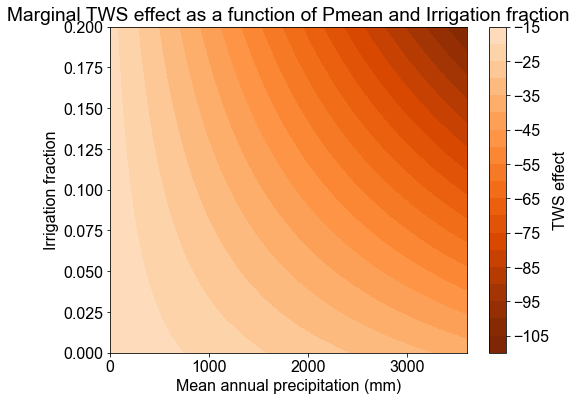

In [112]:
# plot
from matplotlib.colors import TwoSlopeNorm

def twseffect(Pmean,I):
    gamma = -15.6
    chi = -0.006
    GI = -12.8
    GPI = -0.091
    return gamma+chi*Pmean+GI*I+GPI*Pmean*I
    
# define grid
Pmean_vals = np.linspace(0, 3600, 20)  # 0-3600 mm
I_vals = np.linspace(0, 0.2, 20)          # 0-1 irrigation fraction

# create meshgrid
P_grid, I_grid = np.meshgrid(Pmean_vals, I_vals)

# calculate effect at each combination
effect_grid = twseffect(P_grid, I_grid)
norm = TwoSlopeNorm(vmin=effect_grid.min(), vcenter=-50, vmax=1)  # vmax=0 caps colors at 0

plt.figure(figsize=(8,6))
cont = plt.contourf(P_grid, I_grid, effect_grid, cmap='Oranges_r', norm=norm, levels=20)
plt.colorbar(cont, label='TWS effect')
plt.xlabel('Mean annual precipitation (mm)')
plt.ylabel('Irrigation fraction')
plt.title('Marginal TWS effect as a function of Pmean and Irrigation fraction')
plt.show()


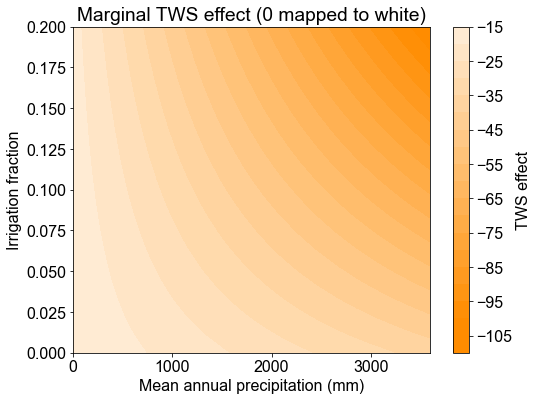

In [120]:
from matplotlib.colors import LinearSegmentedColormap, Normalize


# define grid
Pmean_vals = np.linspace(0, 3600, 20)  
I_vals = np.linspace(0, 0.2, 20)          
P_grid, I_grid = np.meshgrid(Pmean_vals, I_vals)

effect_grid = twseffect(P_grid, I_grid)  # all negative values

# create custom colormap: dark orange for most negative, white for 0
colors = ["darkorange", "white"]  # first = min, second = max
cmap = LinearSegmentedColormap.from_list("orange_to_white", colors)

# normalize from min value to 0 (even if max < 0, white will be at 0)
norm = Normalize(vmin=-100, vmax=0)

plt.figure(figsize=(8,6))
cont = plt.contourf(P_grid, I_grid, effect_grid, cmap=cmap, levels=20, norm=norm)
plt.colorbar(cont, label='TWS effect')
plt.xlabel('Mean annual precipitation (mm)')
plt.ylabel('Irrigated fraction')
plt.title('')
plt.show()

In [94]:
# percent area in irrig frac bin


0.02270666440966424

In [101]:
[pexq_df[pexq_df.irrig_frac>0.2].Pmean.quantile(0.05),pexq_df[pexq_df.irrig_frac>0.2].Pmean.quantile(0.95)]

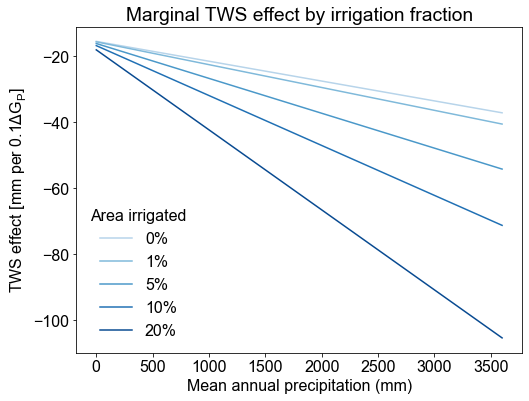

In [124]:
# Pmean range
Pmean_vals = np.linspace(0, 3600, 200)

# selected irrigation fractions
I_vals = [0,0.01, 0.05, 0.1, 0.2 ]

plt.figure(figsize=(8,6))
cmap = plt.get_cmap("Blues")  # built-in sequential colormap
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(I_vals))]

for i,I in enumerate(I_vals):
    if i == 0:
        prange = [pexq_df[pexq_df.irrig_frac<0.0001].Pmean.quantile(0.05),pexq_df[pexq_df.irrig_frac<0.0001].Pmean.quantile(0.95)]
    if i == len(I_vals)-1:
        prange = [pexq_df[pexq_df.irrig_frac>0.2].Pmean.quantile(0.05),pexq_df[pexq_df.irrig_frac>0.2].Pmean.quantile(0.95)]
    else:
        df_bin = pexq_df[(pexq_df['irrig_frac'] > I) & (pexq_df['irrig_frac'] <= I_vals[i+1])]
        prange = [df_bin['Pmean'].quantile(0.05), df_bin['Pmean'].quantile(0.95)]
    
    
    effect = twseffect(Pmean_vals, I)
    plt.plot(Pmean_vals, effect,color=colors[i], label=f'{int(I*100)}%')


plt.xlabel('Mean annual precipitation (mm)')
plt.ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
plt.title('Marginal TWS effect by irrigation fraction')
plt.legend(title='Area irrigated',frameon=False)
plt.grid(False)
plt.show()

In [47]:

earth_radius_m = 6371e3  # meters
deg2rad = np.pi / 180
cell_size_deg = 0.5

# latitudes of cell centers
lat = pexq_df['lat'].values

# compute top/bottom in radians
phi_top = (lat + cell_size_deg/2) * deg2rad
phi_bottom = (lat - cell_size_deg/2) * deg2rad
delta_lon = cell_size_deg * deg2rad

# cell area in m^2
cell_area_m2 = (earth_radius_m**2) * delta_lon * (np.sin(phi_top) - np.sin(phi_bottom))

# convert to hectares (1 ha = 10,000 m^2)
cell_area_ha = cell_area_m2 / 1e4


In [51]:
pexq_df.to_csv(save_dir+'pexq_df_irrig.csv')

aggregate to basin scale 

In [16]:
# aggregate hectares per grid cell equipped for irrigation to basins

import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd
import numpy as np
from shapely.geometry import mapping


# Load raster and get metadata
with rasterio.open(irrig_fn) as src:
    data = src.read(1)  # Read first band
    profile = src.profile
    transform = src.transform
    raster_crs = src.crs
    nodata = profile.get('nodata', -9.0)

# reproject mergedall to match raster CRS
if raster_crs is None:
    raster_crs = 'EPSG:4326'  # Or your known CRS

mergedall = mergedall.to_crs(raster_crs)

# Loop through polygons and compute zonal sum
sums = []

for geom in mergedall['geometry']:
    # Create mask where pixels outside the polygon are True (masked)
    mask = geometry_mask(
        [mapping(geom)],
        transform=transform,
        invert=True,         # We want to keep pixels *inside* the polygon
        out_shape=data.shape
    )
    
    # Masked data
    masked_data = np.where(mask, data, np.nan)
    
    # Ignore nodata values
    if nodata is not None:
        masked_data = np.where(data == nodata, np.nan, masked_data)

    # Sum valid pixels
    zone_sum = np.nansum(masked_data)
    sums.append(zone_sum)

# add the results as a new column
mergedall['aei'] = sums

In [17]:
# average aei % groundwater over basins

# Load raster and get metadata
with rasterio.open(irrig_fn) as src:
    data = src.read(1)  # Read first band
    profile = src.profile
    transform = src.transform
    raster_crs = src.crs
    nodata = profile.get('nodata', -9.0)

# reproject mergedall to match raster CRS
if raster_crs is None:
    raster_crs = 'EPSG:4326'  # Or your known CRS

mergedall = mergedall.to_crs(raster_crs)

# Loop through polygons and compute zonal sum
sums = []

for geom in mergedall['geometry']:
    # Create mask where pixels outside the polygon are True (masked)
    mask = geometry_mask(
        [mapping(geom)],
        transform=transform,
        invert=True,         # We want to keep pixels *inside* the polygon
        out_shape=data.shape
    )
    
    # Masked data
    masked_data = np.where(mask, data, np.nan)
    
    # Ignore nodata values
    if nodata is not None:
        masked_data = np.where(data == nodata, np.nan, masked_data)

    # Sum valid pixels
    zone_sum = np.nanmean(masked_data)
    sums.append(zone_sum)

# add the results as a new column
mergedall['raster_sum'] = sums

In [18]:
# now calculate gw aei as percent of basin:

# gw aei in hectares and convert to km2
gw_aei_km2 = mergedall.aei  * 0.01 #* mergedall.raster_sum/100

# divide by basin area
gw_aei_frac_basin = gw_aei_km2/mergedall.AREA_CALC

# add to mergedall
mergedall['gw_aei_frac_basin'] = gw_aei_frac_basin

In [ ]:
### now similarly chekc Gp effect dependence on station density

In [19]:
#open gpcc and get mean stations per grid
gpcc = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')
ngauge = gpcc.numgauge
ngauge_mean = ngauge.mean(dim='time')

#also get coefficient of variation of station count per grid (% variance)
ngauge_std = ngauge.std(dim='time') / ngauge_mean

In [20]:
# average mean gauges over basins:
import rioxarray

# match crs's 
if ngauge_mean.rio.crs is None:
    ngauge_mean = ngauge_mean.rio.write_crs("EPSG:4326")  # or whatever CRS your data uses

if mergedall.crs != ngauge_mean.rio.crs:
    mergedall = mergedall.to_crs(ngauge_mean.rio.crs)

# convert raster to numpy array and get transform
data = ngauge_mean.squeeze().values  # if it's a DataArray with 1 band
transform = ngauge_mean.rio.transform()
nodata = ngauge_mean.rio.nodata

# loop polygons and avg
results = []

for geom in mergedall.geometry:
    mask = geometry_mask(
        [geom.__geo_interface__],
        transform=transform,
        invert=True,  # keep pixels *inside* polygon
        out_shape=data.shape
    )

    masked_data = np.where(mask, data, np.nan)

    if nodata is not None:
        masked_data = np.where(data == nodata, np.nan, masked_data)

    val = np.nansum(masked_data)
    results.append(val)

# add result to basin geodataframe
mergedall["ngauge_mean_zone"] = results

In [21]:
#avg std of gauges over basins
# match crs's 
if ngauge_std.rio.crs is None:
    ngauge_std = ngauge_std.rio.write_crs("EPSG:4326")  # or whatever CRS your data uses

if mergedall.crs != ngauge_std.rio.crs:
    mergedall = mergedall.to_crs(ngauge_std.rio.crs)

# convert raster to numpy array and get transform
data = ngauge_std.squeeze().values  # if it's a DataArray with 1 band
transform = ngauge_std.rio.transform()
nodata = ngauge_std.rio.nodata

# loop polygons and avg
results = []

for geom in mergedall.geometry:
    mask = geometry_mask(
        [geom.__geo_interface__],
        transform=transform,
        invert=True,  # keep pixels *inside* polygon
        out_shape=data.shape
    )

    masked_data = np.where(mask, data, np.nan)

    if nodata is not None:
        masked_data = np.where(data == nodata, np.nan, masked_data)

    val = np.nanmean(masked_data)
    results.append(val)

# add result to basin geodataframe
mergedall["ngauge_std_zone"] = results

In [22]:
# grab basins with reported effect
sigbasins = mergedall[mergedall['sig_consist'] < 1]

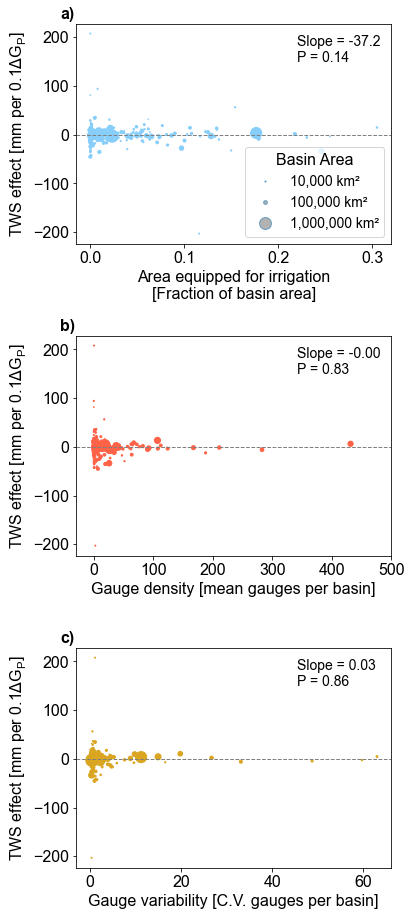

In [23]:
#plot
fig,axs = plt.subplots(3,1,figsize=(6,13))

# a) basin level TWS effect vs irrigation
ax = axs[0]

x = sigbasins.gw_aei_frac_basin.values
y = sigbasins.coef_Gp_mean.values

# mask nans
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
max_area = sigbasins.AREA_CALC.max()
area_scaled = sigbasins.AREA_CALC / max_area * 150
ax.scatter(sigbasins.gw_aei_frac_basin,sigbasins.coef_Gp_mean,s=area_scaled,color='lightskyblue')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.1f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Area equipped for irrigation\n[Fraction of basin area]')


legend_area_vals = [1e4, 1e5, 1e6]  # e.g., 10,000 km², 50,000 km², 100,000 km²

# Scale marker sizes the same way
legend_marker_sizes = [a / max_area * 150 for a in legend_area_vals]

# Create legend handles
legend_handles = [
    Line2D([], [], marker='o', linestyle='None',
           markersize=np.sqrt(ms),  # convert area to diameter in points
           label=f"{int(a):,} km²",  # format with commas and units
           markerfacecolor='gray', alpha=0.6)
    for a, ms in zip(legend_area_vals, legend_marker_sizes)
]

# Add legend
ax.legend(handles=legend_handles, title="Basin Area", loc='lower right', frameon=True,fontsize=14)


### b) basin level TWS effect vs station density
ax = axs[1]

x = sigbasins.ngauge_mean_zone

# Mask to drop NaNs in either array
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

ax.scatter(sigbasins.ngauge_mean_zone,sigbasins.coef_Gp_mean,s=area_scaled,color='tomato')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.2f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

ax.set_xlim(-30,500)
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Gauge density [mean gauges per basin]')

### c) basin level TWS effect vs station variation

ax = axs[2]

x = sigbasins.ngauge_std_zone

# Mask to drop NaNs in either array
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

ax.scatter(sigbasins.ngauge_std_zone,sigbasins.coef_Gp_mean,s=area_scaled,color='goldenrod')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.2f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

#ax.set_xlim(-30,500)
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Gauge variability [C.V. gauges per basin]')

## axis tweaks

lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
plt.tight_layout()

4 panel version with interaction:



In [24]:
pexq_df = pd.read_csv(save_dir+'pexq_df_irrig.csv')

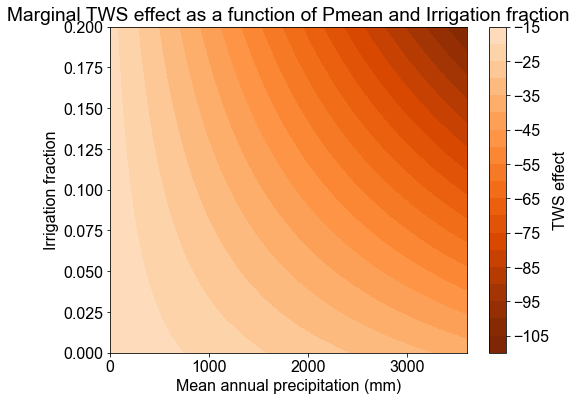

In [112]:
# plot
from matplotlib.colors import TwoSlopeNorm

def twseffect(Pmean,I):
    gamma = -15.6
    chi = -0.006
    GI = -12.8
    GPI = -0.091
    return gamma+chi*Pmean+GI*I+GPI*Pmean*I
    
# define grid
Pmean_vals = np.linspace(0, 3600, 20)  # 0-3600 mm
I_vals = np.linspace(0, 0.2, 20)          # 0-1 irrigation fraction

# create meshgrid
P_grid, I_grid = np.meshgrid(Pmean_vals, I_vals)

# calculate effect at each combination
effect_grid = twseffect(P_grid, I_grid)
norm = TwoSlopeNorm(vmin=effect_grid.min(), vcenter=-50, vmax=1)  # vmax=0 caps colors at 0

plt.figure(figsize=(8,6))
cont = plt.contourf(P_grid, I_grid, effect_grid, cmap='Oranges_r', norm=norm, levels=20)
plt.colorbar(cont, label='TWS effect')
plt.xlabel('Mean annual precipitation (mm)')
plt.ylabel('Irrigation fraction')
plt.title('Marginal TWS effect as a function of Pmean and Irrigation fraction')
plt.show()


In [26]:
# percent area in irrig frac bin
import numpy as np
import pandas as pd

# Your bin edges
I_vals = [0, 0.01, 0.05, 0.1, 0.2]

# 1. Reduce to unique grid cells (since irrig_frac is time-invariant)
df_cells = (
    pexq_df[['lat', 'lon', 'irrig_frac']]
    .drop_duplicates(subset=['lat', 'lon'])
    .copy()
)

# 2. Compute area weights (relative gridcell area)
# Area ∝ cos(latitude)
df_cells['area_weight'] = np.cos(np.deg2rad(df_cells['lat']))

# 3. Bin irrig_frac
bin_edges = I_vals + [np.inf]
bin_labels = [
    '[0, 0.01)',
    '[0.01, 0.05)',
    '[0.05, 0.1)',
    '[0.1, 0.2)',
    '>= 0.2'
]

df_cells['irrig_bin'] = pd.cut(
    df_cells['irrig_frac'],
    bins=bin_edges,
    labels=bin_labels,
    right=False
)

# 4. Compute area fraction per bin
area_by_bin = (
    df_cells
    .groupby('irrig_bin')['area_weight']
    .sum()
)

total_area = df_cells['area_weight'].sum()

frac_area_by_bin = area_by_bin / total_area




In [27]:
def twseffect(Pmean,I):
    gamma = -15.6
    chi = -0.006
    GI = -12.8
    GPI = -0.091
    return gamma+chi*Pmean+GI*I+GPI*Pmean*I
    
# function to compute 95% estimation CI of fit
def intSE(y,se_Gp,se_GpP,cov,scale=1,n_se=2):
    variance = se_Gp**2 + (x**2) * se_GpP**2 + 2*x * cov
    se = np.sqrt(variance)
    effecthi = y+scale*n_se*se
    effectlo = y-scale*n_se*se
    return effectlo,effecthi


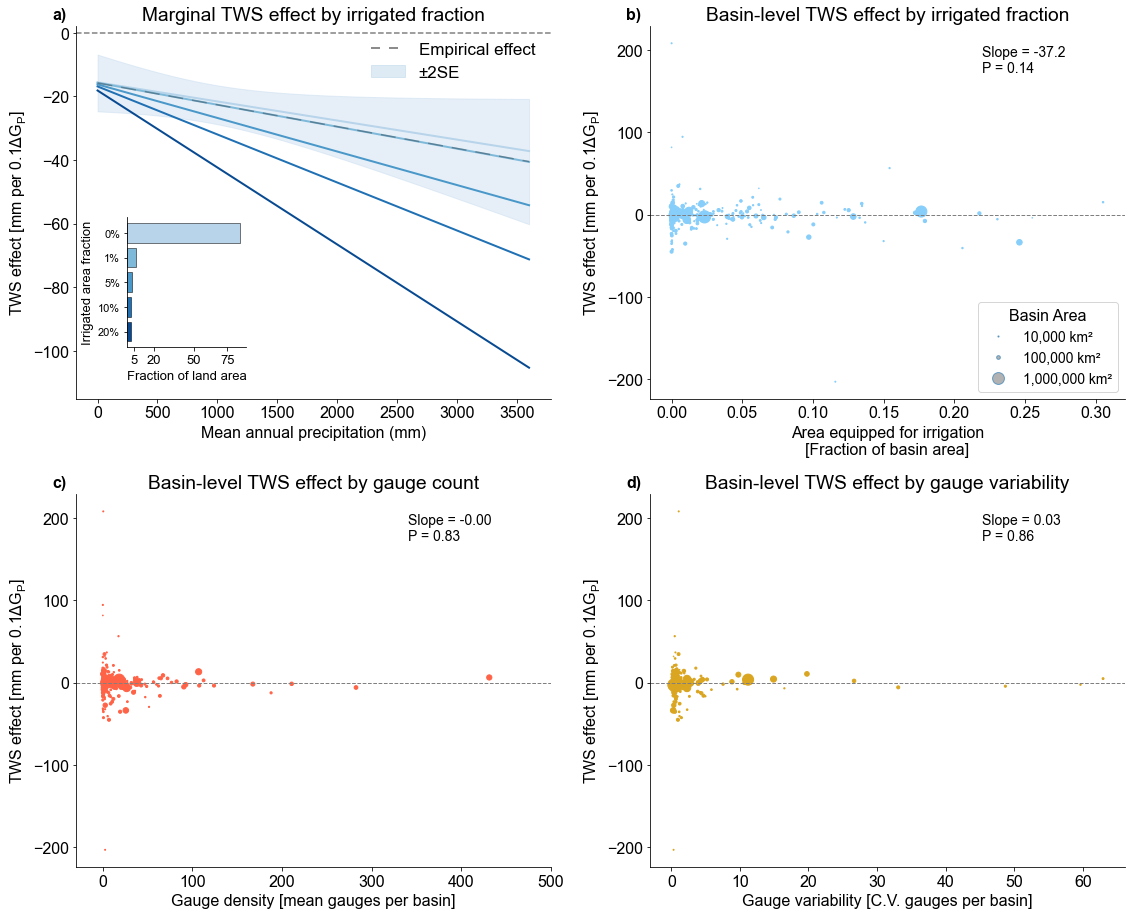

In [45]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#plot
fig,axs = plt.subplots(2,2,figsize=(16,13))
axs = axs.reshape(-1)

# a) interaction
ax =axs[0]

# Pmean range
Pmean_vals = np.linspace(0, 3600, 200)

# selected irrigation fractions
I_vals = [0,0.01, 0.05, 0.1, 0.2 ]

x=Pmean_vals
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')
y_cpc = 1*cpc_results.coef_Gp[0]+1*cpc_results.coef_GpP[0]*x
effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])


cmap = plt.get_cmap("Blues")  # built-in sequential colormap
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(I_vals))]

for i,I in enumerate(I_vals):

    
    effect = twseffect(Pmean_vals, I)
    ax.plot(Pmean_vals, effect,color=colors[i],linewidth=2,label=f'{int(I*100)}%')
    
ax.plot(x,y_cpc,color='k',linestyle=(0, (10, 6)),alpha=0.3)
ax.fill_between(x,effectlo_cpc,effecthi_cpc,color='#aecde8',alpha=0.3)

l0=ax.plot([],[],color='k',linestyle=(0, (6, 6)),alpha=0.6)
f0=ax.fill_between([],[],[],color='#aecde8',alpha=0.4)

ax.axhline(0,linestyle='--',color='grey')
ax.set_ylim([-115,2])
#histogram
axins = inset_axes(
    ax,
    width="25%",   # percent of parent axis
    height="35%",
    loc="lower left",
    borderpad=3.2
)

area_fracs = frac_area_by_bin.values

# Bar plot
axins.barh(
    range(len(I_vals)),
    100*area_fracs,
    color=colors,
    edgecolor='k',
    linewidth=0.5
)

# Formatting
axins.set_yticks(range(len(I_vals)))
axins.set_yticklabels([f'{int(I*100)}%' for I in I_vals], fontsize=11)
axins.set_ylabel('Irrigated area fraction', fontsize=13)
axins.set_xlabel('Fraction of land area',fontsize=13)
axins.invert_yaxis()
axins.tick_params(axis='x', labelsize=13)
axins.set_xticks([5, 20, 50, 75])
axins.spines[['right', 'top']].set_visible(False)

#axes

ax.set_xlabel('Mean annual precipitation (mm)')
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_title('Marginal TWS effect by irrigated fraction')
ax.legend([l0[0],f0],['Empirical effect','±2SE'],loc='upper right',fontsize=17,frameon=False)
                                        
                                        
# b) basin level TWS effect vs irrigation
ax = axs[1]

x = sigbasins.gw_aei_frac_basin.values
y = sigbasins.coef_Gp_mean.values

# mask nans
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
max_area = sigbasins.AREA_CALC.max()
area_scaled = sigbasins.AREA_CALC / max_area * 150
ax.scatter(sigbasins.gw_aei_frac_basin,sigbasins.coef_Gp_mean,s=area_scaled,color='lightskyblue')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.1f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Area equipped for irrigation\n[Fraction of basin area]')
ax.set_title('Basin-level TWS effect by irrigated fraction')

legend_area_vals = [1e4, 1e5, 1e6]  # e.g., 10,000 km², 50,000 km², 100,000 km²

# Scale marker sizes the same way
legend_marker_sizes = [a / max_area * 150 for a in legend_area_vals]

# Create legend handles
legend_handles = [
    Line2D([], [], marker='o', linestyle='None',
           markersize=np.sqrt(ms),  # convert area to diameter in points
           label=f"{int(a):,} km²",  # format with commas and units
           markerfacecolor='gray', alpha=0.6)
    for a, ms in zip(legend_area_vals, legend_marker_sizes)
]

# Add legend
ax.legend(handles=legend_handles, title="Basin Area", loc='lower right', frameon=True,fontsize=14)


### c) basin level TWS effect vs station density
ax = axs[2]

x = sigbasins.ngauge_mean_zone

# Mask to drop NaNs in either array
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

ax.scatter(sigbasins.ngauge_mean_zone,sigbasins.coef_Gp_mean,s=area_scaled,color='tomato')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.2f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

ax.set_xlim(-30,500)
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Gauge density [mean gauges per basin]')
ax.set_title('Basin-level TWS effect by gauge count')

### c) basin level TWS effect vs station variation

ax = axs[3]

x = sigbasins.ngauge_std_zone

# Mask to drop NaNs in either array
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

ax.scatter(sigbasins.ngauge_std_zone,sigbasins.coef_Gp_mean,s=area_scaled,color='goldenrod')

ax.axhline(0,linestyle='--',linewidth=1,color='grey')
# Annotate slope and p-value on the plot
ax.annotate(
    f"Slope = {slope:.2f}\nP = {p_value:.2g}",
    xy=(0.70, 0.95), xycoords='axes fraction',
    ha='left', va='top',
    fontsize=14,
    #bbox=dict(boxstyle='pad=0.3', facecolor='white', alpha=0.7)
)

#ax.set_xlim(-30,500)
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_xlabel('Gauge variability [C.V. gauges per basin]')
ax.set_title('Basin-level TWS effect by gauge variability')

## axis tweaks

lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

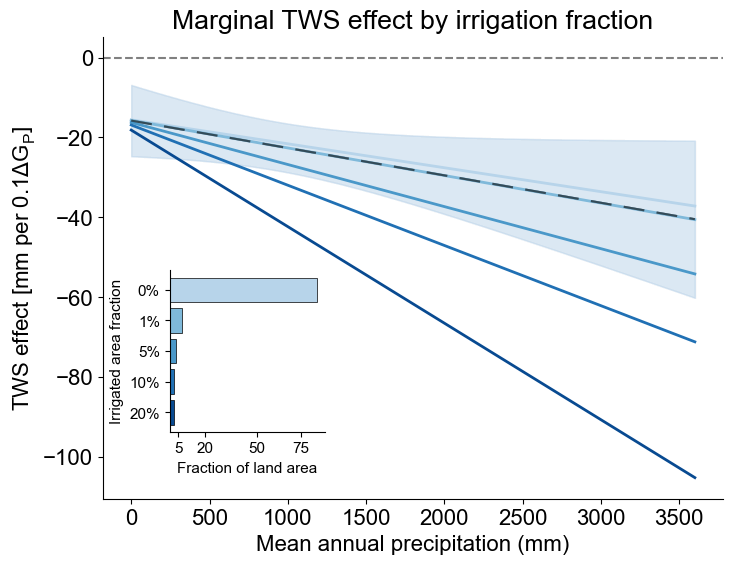

In [70]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Pmean range
Pmean_vals = np.linspace(0, 3600, 200)

# selected irrigation fractions
I_vals = [0,0.01, 0.05, 0.1, 0.2 ]

fig,ax = plt.subplots(figsize=(8,6))

x=Pmean_vals
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')
y_cpc = 1*cpc_results.coef_Gp[0]+1*cpc_results.coef_GpP[0]*x
effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])


cmap = plt.get_cmap("Blues")  # built-in sequential colormap
colors = [cmap(i) for i in np.linspace(0.3, 0.9, len(I_vals))]

for i,I in enumerate(I_vals):

    
    effect = twseffect(Pmean_vals, I)
    ax.plot(Pmean_vals, effect,color=colors[i],linewidth=2,label=f'{int(I*100)}%')
    
    l0=ax.plot(x,y_cpc,color='k',linestyle=(0, (10, 6)),alpha=0.2)
    f0=ax.fill_between(x,effectlo_cpc,effecthi_cpc,color='#aecde8',alpha=0.1)

ax.axhline(0,linestyle='--',color='grey')

#histogram
axins = inset_axes(
    ax,
    width="25%",   # percent of parent axis
    height="35%",
    loc="lower left",
    borderpad=3
)

area_fracs = frac_area_by_bin.values

# Bar plot
axins.barh(
    range(len(I_vals)),
    100*area_fracs,
    color=colors,
    edgecolor='k',
    linewidth=0.5
)

# Formatting
axins.set_yticks(range(len(I_vals)))
axins.set_yticklabels([f'{int(I*100)}%' for I in I_vals], fontsize=11)
axins.set_ylabel('Irrigated area fraction', fontsize=11)
axins.set_xlabel('Fraction of land area',fontsize=11)
axins.invert_yaxis()
axins.tick_params(axis='x', labelsize=11)
axins.set_xticks([5, 20, 50, 75])
axins.spines[['right', 'top']].set_visible(False)

#axes

ax.set_xlabel('Mean annual precipitation (mm)')
ax.set_ylabel(r"TWS effect [mm per 0.1$\Delta G_P$]")
ax.set_title('Marginal TWS effect by irrigation fraction')
#ax.legend(title='Area irrigated',fontsize=12,frameon=False)
ax.spines[['right', 'top']].set_visible(False)
